# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Early Alfa Sheilawati
- **Email:** cdcc525d6x0093@student.devacademy.id
- **ID Dicoding:** CDCC525D6X0093

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**Bisnis: Bike Sharing Dataset**

**Pertanyaan bisnis yang saya ambil dari data yang tersedia:**

- **Pertanyaan 1:** Bagaimana tren total penyewaan sepeda secara bulanan selama periode tahun 2011 hingga 2012 untuk melihat pertumbuhan bisnis?
- **Pertanyaan 2:** Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewa sepeda harian, dan pada kondisi cuaca apa promosi khusus perlu dilakukan untuk meningkatkan penyewaan?
- **Pertanyaan 3:** Berbandingan jumlah penyewa sepeda antara tipe pengguna Casual dan Registered pada jam-jam sibuk (07:00 - 09:00 dan 17:00 - 19:00) selama hari kerja tahun 2012?

## Import Semua Packages/Library yang Digunakan

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

*Tahap ini memuat data dari file CSV yang tersedia untuk diolah ke tahap selanjutnya*.

In [242]:
# Data Harian
day_df = pd.read_csv("/content/drive/MyDrive/Dicoding Spreadsheet/Dicoding_Analisis data/day.csv")

# Data Per jam
hour_df = pd.read_csv("/content/drive/MyDrive/Dicoding Spreadsheet/Dicoding_Analisis data/hour.csv")

# Menampilkan 5 baris pertama data dari harian
print("Tampilan awal data day_df:")
display(day_df.head())

Tampilan awal data day_df:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Memuat dua file , yaitu day.csv dan hour.csv
- Kedua kolom sama, tetapi file hour lebih detail karena mencatat aktivitas tiap jam.

### Assessing Data

*Pada tahap ini dilakukan untuk memeriksa kualitas data agar saat mengidentifikasi tau adanya missing values, duplikasi data, dan ketidaksesuaian tipe data pada kolom tertentu*.

In [243]:
# Cek tipe data dan missing values
print("Informasi data day_df:")
day_df.info()

Informasi data day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [244]:
# Cek jumlah duplikasi
print("Jumlah duplikasi pada day_df:", day_df.duplicated().sum())

Jumlah duplikasi pada day_df: 0


In [245]:
# Cek ringkasan statistik
print("Statistik deskriptif data day_df:")
display(day_df.describe())

Statistik deskriptif data day_df:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengubah kolom dteday dari tipe data object menjadi datetime.
- Melakukan mapping atau mengubah angka di kolom season, yr, dan weathersit menjadi label teks (seperti Spring, 2012, Clear) agar grafik nantinya mudah dibaca.
- Memastikan tidak ada nilai kosong atau duplikat yang bisa merusak hasil analisis.

**Insight:** (Opsional)
- Data ini tidak ada yang kosong (missing vallues) atau duplikat barisnya.
- Format tanggalnya masih teks biasa dan kolom kategorinya sulit untuk dijadikan grafik.

### Cleaning Data

*Tahap ini melakukan pembersihan data berdasarkan yang ditemukan pada tahap Assesing Data untuk memperbaiki tipe data dan mengubah angka jadi tabel informatif.*

In [246]:
# Mengubah kolom dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping Musim
day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Mapping Kondisi Cuaca
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear',
    2: 'Misty',
    3: 'Light Snow',
    4: 'Severe Weather'
})

# Mapping Tahun (0: 2011, 1: 2012)
day_df['yr'] = day_df['yr'].map({
    0: '2011', 1: '2012'
})

# Menampilkan hasil akhir
print("Data harian setelah proses pembersihan:")
display(day_df.head())

Data harian setelah proses pembersihan:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,Misty,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,Misty,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Data sudah bersih
- Kolom format sudah benar.
- Kolom musim dan cuaca sudah berubah jadi kata informatif, agar jika dijadikan grafik sangat jelas dan mudah dipahami.

## Exploratory Data Analysis (EDA)

*Tahap eksplorasi dari data yang sudah dibersihkan untuk mendapatkan wawasan (insight) dan menjawab pertanyaan analitis. Memperlihatkan hubungan tidak terlihat sebelumnya*.

In [247]:
# Pertanyaan 1: Tren bulanan per tahun
print("Total penyewaan bulanan (2011-2012):")
display(day_df.groupby(by=["yr", "mnth"]).agg({
    "cnt": "sum"
}))

Total penyewaan bulanan (2011-2012):


cnt
yr   mnth        
2011 1      38189
     2      48215
     3      64045
     4      94870
     5     135821
     6     143512
     7     141341
     8     136691
     9     127418
     10    123511
     11    102167
     12     87323
2012 1      96744
     2     103137
     3     164875
     4     174224
     5     195865
     6     202830
     7     203607
     8     214503
     9     218573
     10    198841
     11    152664
     12    123713

In [248]:
# Pertanyaan 2: Pengaruh cuaca
print("Rata-rata penyewaan berdasarkan kondisi cuaca:")
display(day_df.groupby(by="weathersit").agg({
    "cnt": "mean"
}).sort_values(by="cnt", ascending=False))

Rata-rata penyewaan berdasarkan kondisi cuaca:


,cnt
weathersit,
Clear,4876.786177
Misty,4035.862348
Light Snow,1803.285714


In [249]:
# Pertanyaan 3: Perbandingan Casual vs Registered di jam sibuk
# Filter hari kerja dan jam sibuk
working_hours = hour_df[(hour_df["workingday"] == 1) &
                        (hour_df["hr"].isin([7, 8, 9, 17, 18, 19]))]

print("Perbandingan Casual vs Registered di jam sibuk (Hari Kerja):")
display(working_hours.agg({
    "casual": "sum",
    "registered": "sum"
}))

Perbandingan Casual vs Registered di jam sibuk (Hari Kerja):


,0
casual,103096
registered,1078189


**Insight:** (Opsional)
- Penyewa tahun 2012 lebih besar dibandingkan tahun 2011.
- Cuaca cerah mendominasi jumlah penyewaan daripada saat cuaca buruk (hujan/salju).
- Lebih banyak penyewa di jam sibuk dibandingkan jam casual.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

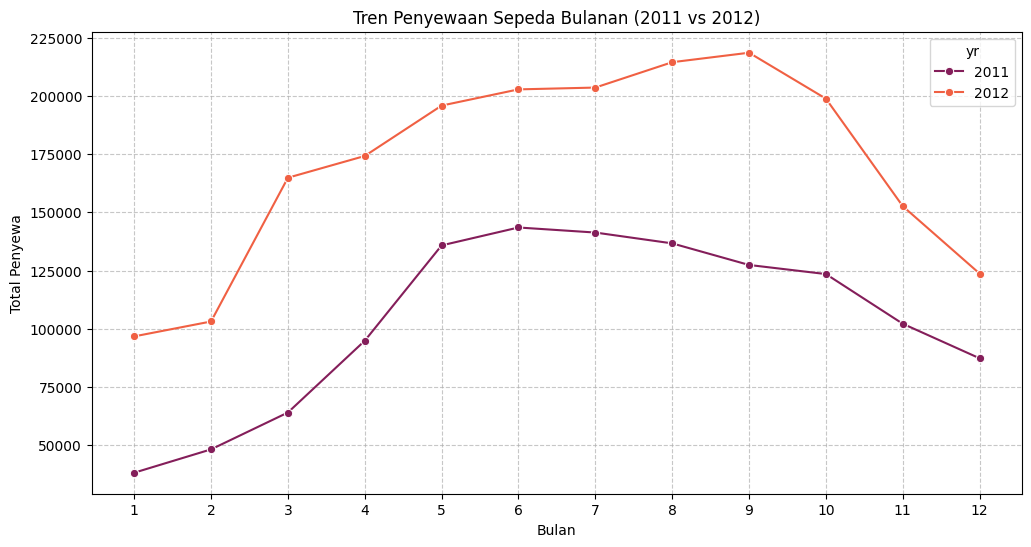

In [250]:
plt.figure(figsize=(12, 6))
monthly_trend = day_df.groupby(by=["yr", "mnth"]).agg({"cnt": "sum"}).reset_index()

sns.lineplot(data=monthly_trend, x="mnth", y="cnt", hue="yr", marker="o", palette="rocket")
plt.title("Tren Penyewaan Sepeda Bulanan (2011 vs 2012)")
plt.xlabel("Bulan")
plt.ylabel("Total Penyewa")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Insight:** (Opsional)
- Grafik garis menunjukkan kenaikan volume penyewaan yang stabil dari tahun 2011 ke 2012. Puncaknya selalu terjadi di pertengahan tahun (sekitar bulan Mei hingga September).
- Bisnis dipengaruhi oleh penggatian musim.

### Pertanyaan 2:

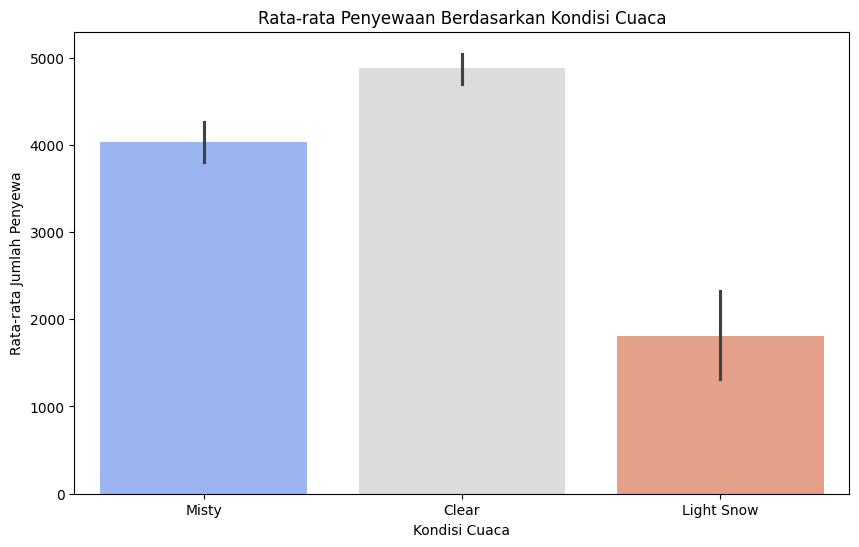

In [251]:
plt.figure(figsize=(10, 6))
sns.barplot(data=day_df, x="weathersit", y="cnt", palette="coolwarm", hue="weathersit", legend=False)
plt.title("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Jumlah Penyewa")
plt.show()

**Insight:** (Opsional)
- Penyewaan rata-rata paling tinggi saat cuaca Cerah/Berawan.
- Cuaca mulai turun hujan dan bersalju, penyewaan anjlok drastis.
- Mengkin dilakukan promosi khusus (Diskon) saat cuaca buruk untuk menarik peminat tetap bersepeda.

### Pertanyaan 3:

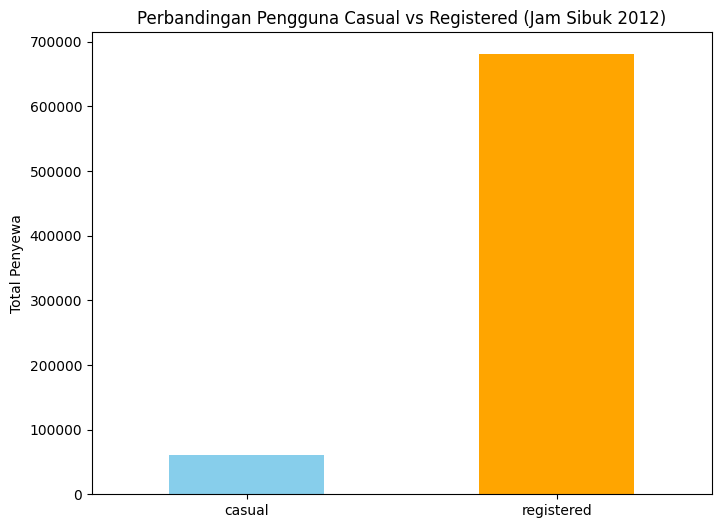

In [252]:
# Menyiapkan data jam sibuk tahun 2012
rush_hour_2012 = hour_df[(hour_df["yr"] == 1) & (hour_df["workingday"] == 1) & (hour_df["hr"].isin([7,8,9,17,18,19]))]
comparison = rush_hour_2012[["casual", "registered"]].sum()

plt.figure(figsize=(8, 6))
comparison.plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Perbandingan Pengguna Casual vs Registered (Jam Sibuk 2012)")
plt.ylabel("Total Penyewa")
plt.xticks(rotation=0)
plt.show()

**Insight:** (Opsional)
- Pengguna registered (jam sibuk) berkali lipat lebih banyak daripada pengguna casual (jam biasa).
- Penyewa di jam sibuk adalah pekerja atau pelajar yang menggunkan transportasi rutin untuk mobilitas harian.

## Analisis Lanjutan (Opsional)

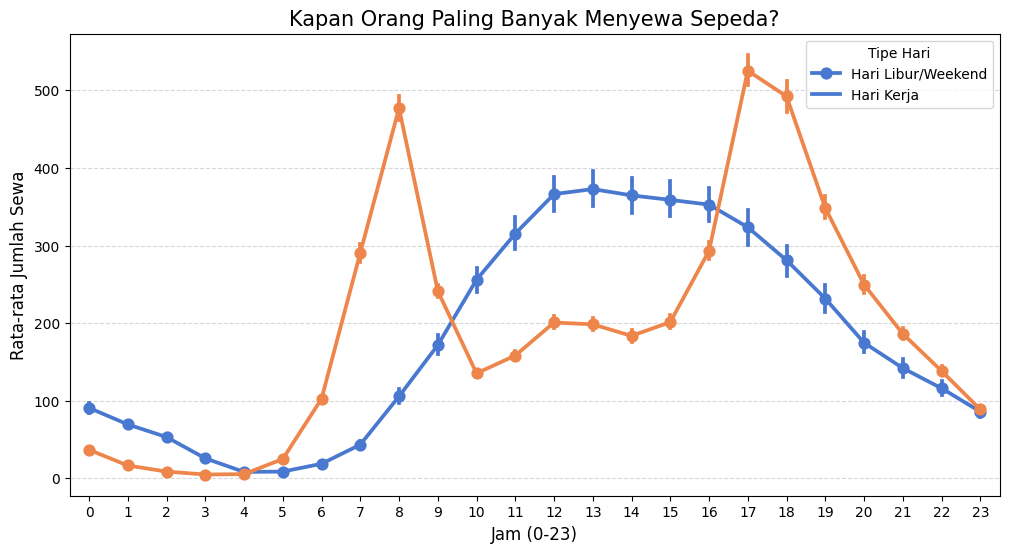

In [253]:
# 1. Menyiapkan area gambar agar luas
plt.figure(figsize=(12, 6))

# 2. Membuat grafik garis (pointplot) untuk membandingkan Hari Kerja vs Libur
sns.pointplot(
    data=hour_df,
    x="hr",
    y="cnt",
    hue="workingday",
    palette="muted"
)

# 3. Memberikan judul dan label yang mudah dibaca
plt.title("Kapan Orang Paling Banyak Menyewa Sepeda?", fontsize=15)
plt.xlabel("Jam (0-23)", fontsize=12)
plt.ylabel("Rata-rata Jumlah Sewa", fontsize=12)

# 4. Memberikan keterangan warna (Legend)
plt.legend(title="Tipe Hari", labels=["Hari Libur/Weekend", "Hari Kerja"])

# 5. Menambah garis bantu (grid) agar angka jamnya gampang dilihat
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. Menampilkan grafik
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Total penyewaan sepeda terus meningkat secara signifikan dari tahun 2011 ke 2012, membuktikan bisnis ini tumbuh pesat.
- **Conclusion pertanyaan 2:** Cuaca cerah adalah pendorong utama penyewaan. Sebaliknya, cuaca buruk membuat jumlah pengguna menurun drastis.
- **Conclusion pertanyaan 3:** Di hari kerja, orang menyewa sepeda di jam sibuk (08.00 & 17.00). Di hari libur, orang lebih santai dan banyak menyewa di tengah hari (11.00 - 15.00).

**Rekomendasi Action Item:**
- Fokus pada pesewaan sepeda di area perkantoran pada jam sibuk dihari kerja.
- Buatlah iklan diskon khusus (Weekend Ceria) untuk meningkatkan penyewaan dihari libur.
- Menyediakan jas hujan atau fasilitas yang mendukung sepeda saat penggunaan di cuaca mendung.

In [254]:
day_df.to_csv("main_data.csv", index=False)